In [1]:
import math
import os
import time
import sys
sys.path.append(os.path.abspath('.')) # to run files that are away
os.environ["WANDB_SILENT"] = "true"  # Suppress WandB logs

libraries = ["torch", "numpy", "polars"]
modules   = {lib: sys.modules.get(lib) for lib in libraries}

if not modules["torch"]:
    import torch
if not modules["numpy"]:
    import numpy as np
if not modules["polars"]:
    import polars as pl

import pandas as pd
import gc
import catboost as cb
import lightgbm as lgb
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from load_and_rename_files import LogFilesProcessor, WaferFilesProcessor
from prediction_methods import MultiOutputModelPredictor, DataPreprocessor
from asm_utils import count_missing_values_in_df, plot_all_columns_in_df, remove_constant_valued_cols, estimate_dataset_dimensionality

device = torch.device('mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu'))

def beep_sound(times=1, delay=0.2):
    for _ in range(times):
        os.system('afplay /System/Library/Sounds/Blow.aiff')
        time.sleep(delay)

import asm_data_wrangling as asm
from key_params import NUM_WAFERS, step_col_name, COMMON_ID_COLS, COMMON_ID_COLS_MOD, parquet_folder_name #, dict_of_spatial_files, dict_of_log_files 

log_processor = LogFilesProcessor(COMMON_ID_COLS_MOD, COMMON_ID_COLS)


In [2]:
main_folder   = "../ASM_data"
dict_of_spatial_files = {'file1': {'path': f"{main_folder}/2. marathon0/Wafer performance/Spatial property after step 4.csv", 'marathon': 0},
                         'file2': {'path': f"{main_folder}/3. marathon1/Wafer performance/Spatial property.csv", 'marathon': 1}}

dict_of_log_files = {'file1': {'path': f"{main_folder}/2. marathon0/logs/Step1.csv", 'step': 1, 'marathon': 0},
                     'file2': {'path': f"{main_folder}/2. marathon0/logs/Step2.csv", 'step': 2, 'marathon': 0},
                     'file3': {'path': f"{main_folder}/2. marathon0/logs/Step3.csv", 'step': 3, 'marathon': 0},
                     'file4': {'path': f"{main_folder}/2. marathon0/logs/Step4.csv", 'step': 4, 'marathon': 0},
                     'file5': {'path': f"{main_folder}/3. marathon1/logs/Step1.csv", 'step': 1, 'marathon': 1},
                     'file6': {'path': f"{main_folder}/3. marathon1/logs/Step2.csv", 'step': 2, 'marathon': 1},
                     'file7': {'path': f"{main_folder}/3. marathon1/logs/Step3.csv", 'step': 3, 'marathon': 1},
                     'file8': {'path': f"{main_folder}/3. marathon1/logs/Step4.csv", 'step': 4, 'marathon': 1},}


In [3]:
"""code to have split into 4 wafers"""

# master_spatial_df, spatial_df_dict, y_df_dict, radius_wide_dict = asm.load_spatial_csv_and_create_targets(dict_of_spatial_files, main_folder, save=False)
# unique_marathon_runs_list = list(master_spatial_df["marathon_run"].unique())
# master_log_df = asm.load_process_and_combine_log_csv_files(dict_of_log_files, log_processor, unique_marathon_runs_list, step_col_name, main_folder, save=False)
# # master_log_df = master_log_df.fill_null(pl.lit(0))
# master_log_df = remove_constant_valued_cols(master_log_df)
# master_log_df = master_log_df.fill_null(pl.lit(0))

# # asm.dont_split_log_df_by_wafer_and_save_to_parquet(master_log_df, main_folder, overwrite = True)
# # asm.split_log_df_by_wafer_and_save_to_parquet(master_log_df, NUM_WAFERS, main_folder, log_processor, overwrite = True)

# # log_df_with_wafer_col = asm.infer_wafer_from_rc_values(master_log_df, rc_prefix="rc", wafer_col="wafer", overwrite = False)
# # log_df_with_wafer_col = asm.fast_infer_wafer(master_log_df, NUM_WAFERS)


'code to have split into 4 wafers'

In [4]:
"""Code (new) to have a unified code/model (NOT split per wafer)"""

def explode_log_df_rows_by_wafer(log_df: pl.DataFrame, num_wafers: int) -> pl.DataFrame:
    """The original df had many wafers processed per row. This function expands each row to 4 rows, 1 row dedicated to each wafer,
    keeping common columns unchanged and zeroing out rc# columns not belonging to the current wafer. 
    Adds a 'wafer' column to identify the active wafer per row"""
    wafer_col       = "wafer"
    step_id_col     = "step_id"
    marathon_run_col= "marathon_run"
    process_time_col= "process time"
    rc_prefix       = "rc"

    rc_cols     = [c for c in log_df.columns if c.startswith(rc_prefix)]
    common_cols = [c for c in log_df.columns if not c.startswith(rc_prefix)]
    wafer_rows  = []

    for i in range(1, num_wafers + 1):
        wafer_prefix = f"{rc_prefix}{i}"
        zero_exprs   = []
        for c in rc_cols:
            if c.startswith(wafer_prefix):
                zero_exprs.append(pl.col(c)) # keep original
            else:
                dtype    = log_df.schema[c]
                zero_val = 0.0 if dtype == pl.Float64 else 0
                zero_exprs.append(pl.lit(zero_val).cast(dtype).alias(c))
        wafer_df = log_df.select([pl.col(c) for c in common_cols] + zero_exprs)
        wafer_df = wafer_df.with_columns(pl.lit(i).alias(wafer_col))

        # insert 'wafer' after 'step_id'
        if step_id_col in wafer_df.columns:
            cols = wafer_df.columns
            if wafer_col in cols:
                cols.remove(wafer_col) # avoid duplicate
            idx      = cols.index(step_id_col)
            wafer_df = wafer_df.select(cols[:idx + 1] + [wafer_col] + cols[idx + 1:])
        wafer_rows.append(wafer_df)
    return pl.concat(wafer_rows, how = "vertical").sort([process_time_col, marathon_run_col, wafer_col])

def load_spatial_csv_files_to_1_df(dict_of_spatial_files):
    """Load and vertically concat every spatial csv to a combined df"""
    rc_prefix    = "RC"
    run_col      = "#Run"
    marathon_col = "marathon"
    marathon_run_col = "marathon_run"
    wafer_col    = "wafer"

    all_dfs = []
    for file_info in dict_of_spatial_files.values():
        path       = file_info["path"]
        marathon   = file_info[marathon_col]
        spatial_df = pl.read_csv(path)
        spatial_df = (spatial_df.with_columns([
                (pl.lit(str(marathon)) + "_" + pl.col(run_col).cast(pl.Utf8)).alias(marathon_run_col),]).rename({rc_prefix: wafer_col}))
        all_dfs.append(spatial_df)
    master_spatial_df = pl.concat(all_dfs, how = "vertical")

    
    unique_marathon_runs_list = list(master_spatial_df[marathon_run_col].unique())

    return master_spatial_df, unique_marathon_runs_list

def create_target_df_from_spatial_df(master_spatial_df, main_folder: str, save: bool = False) -> tuple:
    """Given the combined spatial df, split it to 1 radius_df (that we join to X), and 1 y_df
    wide_radius_df: 1 row per (marathon_run, wafer) combo, column names = "Site ID" values"""
    wafer_col        = "wafer"
    marathon_run_col = "marathon_run"
    radius_col       = "Radius (mm)"
    site_id_col      = "Site #"
    spatial_prop_col = "Spatial property (nm)"

    wide_radius_df = (master_spatial_df
        .select([marathon_run_col, wafer_col, site_id_col, radius_col])
        .pivot(values  = radius_col,
               index   = [marathon_run_col, wafer_col],
               columns = site_id_col,
               aggregate_function = "first")
        .sort([marathon_run_col, wafer_col]))

    y_df = (master_spatial_df
        .select([marathon_run_col, wafer_col, site_id_col, spatial_prop_col])
        .pivot(values  = spatial_prop_col,
               index   = [marathon_run_col, wafer_col],
               columns = site_id_col,
               aggregate_function = "first")
        .sort([marathon_run_col, wafer_col]))

    # if save:
    #     master_spatial_df.write_parquet(f"{main_folder}/master_spatial_df.parquet")
    return wide_radius_df, y_df

def join_radius_df_to_exploded_log_df(master_log_df_exploded, wide_radius_df):
    """joining radius_df and exploded_log_df = X (used for predictions)"""
    return master_log_df_exploded.join(wide_radius_df,
                                       on  = ["marathon_run", "wafer"],
                                       how = "left")

def expand_y_df_to_match_size_of_log_df(master_log_df_exploded, y_df):
    """This gives us y"""
    identifiers_list = ["marathon_run", "wafer"]
    # Step 1: ensure y_df has just the keys and values
    y_lookup = y_df.clone()

    # Step 2: select matching keys from log df in order
    keys_df = master_log_df_exploded.select(identifiers_list)

    # Step 3: join to align rows in y_df_expanded
    y_df_expanded = keys_df.join(y_lookup, on = identifiers_list, how = "left")
    return y_df_expanded

# def downsample_df_rows(log_df: pl.DataFrame, subsampling_factor: int) -> pl.DataFrame:
#     """Downsamples the # of rows by a factor. Larger factor = smaller resulting dataset"""
#     marathon_run_col = "marathon_run"
#     unique_run_value = log_df[marathon_run_col].unique()
#     subsampled_parts = []

#     for run in unique_run_value:
#         group_df = log_df.filter(pl.col(marathon_run_col) == run)
#         subsampled_parts.append(group_df[::subsampling_factor])
#     log_df_subsampled = pl.concat(subsampled_parts)
#     return log_df_subsampled

def downsample_df_rows(log_df: pl.DataFrame, subsampling_factor: int) -> pl.DataFrame:
    """Downsamples the # of rows (grouped by marathon_run, wafer) by a factor. Larger factor = smaller resulting dataset
    NOTE: Grouping by wafer ensures we retain data from all wafers; without it, some wafers might be entirely excluded"""

    marathon_run_col = "marathon_run"
    wafer_col        = "wafer"
    time_col         = "process time"
    subsampled_parts = []

    for (_, _), group_df in log_df.group_by([marathon_run_col, wafer_col]):
        group_df = group_df.sort(time_col) # preserve time order within group
        subsampled_parts.append(group_df[::subsampling_factor])
    
    return pl.concat(subsampled_parts).sort(time_col)

master_spatial_df, unique_marathon_runs_list = load_spatial_csv_files_to_1_df(dict_of_spatial_files)
wide_radius_df, y_df   = create_target_df_from_spatial_df(master_spatial_df, main_folder, save=False)
del master_spatial_df
# ====
master_log_df = asm.load_process_and_combine_log_csv_files(dict_of_log_files, log_processor, unique_marathon_runs_list, step_col_name, main_folder, save=False)
master_log_df = remove_constant_valued_cols(master_log_df)
master_log_df = master_log_df.fill_null(pl.lit(0))
# ====
master_log_df_exploded = explode_log_df_rows_by_wafer(master_log_df, NUM_WAFERS)
master_log_df_exploded = remove_constant_valued_cols(master_log_df_exploded)

del master_log_df


In [5]:
# Categorical if unique count is small relative to length
def is_cyclic(series):
    try:
        values = series.cast(pl.Float64).to_numpy()
        return np.all(np.isfinite(values)) and (values.max() - values.min()) == 360
    except:
        return False

master_log_df_exploded2 = master_log_df_exploded.drop("process time")
cyclic_counter = 0
for col in master_log_df_exploded2.columns:
    is_col_cyclic = is_cyclic(master_log_df_exploded2[col])
    # print(f"{col}: {is_col_cyclic}")
    cyclic_counter += 1

print(cyclic_counter)


597


In [6]:
# ~~~~~~~ whittle down master_log_df_exploded shape here
# consider only 1 step
only_step_4 = master_log_df_exploded.filter(pl.col("step_id") == 4)

# subsample df
N_downsampling    = 50
subsampled_log_df = downsample_df_rows(only_step_4, N_downsampling)

# latest rows per run:
# num_last_rows_per_run = 200
# latest_rows_per_run   = (only_step_4.sort("process time").group_by(["marathon_run", "wafer"]).tail(num_last_rows_per_run))
# ~~~~~~~~~~~~

log_df_with_no_constant_cols  = remove_constant_valued_cols(subsampled_log_df)
joined_log_df_with_spatial_df = join_radius_df_to_exploded_log_df(log_df_with_no_constant_cols, wide_radius_df)
y_df_expanded                 = expand_y_df_to_match_size_of_log_df(joined_log_df_with_spatial_df, y_df)
joined_log_spatial_df_no_str  = joined_log_df_with_spatial_df.select(pl.exclude(pl.Utf8)) # remove str cols

try:
    del only_step_4, log_df_with_no_constant_cols,\
        joined_log_df_with_spatial_df #, master_log_df_exploded, wide_radius_df, y_df
except NameError:
    pass


In [7]:
def predict_catboost(X_train: np.ndarray, y_train: np.ndarray, X_val: np.ndarray, y_val: np.ndarray):
    """CatBoost only accepts uppercase 'task_type', beware of that"""
    model = MultiOutputRegressor(cb.CatBoostRegressor(iterations         = 50,
                                                        learning_rate      = 0.4,
                                                        depth              = 8,
                                                        l2_leaf_reg        = 3,
                                                        border_count       = 128,
                                                        bagging_temperature= 0,
                                                        task_type          = 'CPU',
                                                        verbose            = 0,
                                                        random_seed        = 42))
    model.fit(X_train, y_train)
    importances= np.array([est.get_feature_importance() for est in model.estimators_])
    y_pred_cat = model.predict(X_val)
    rmse_cat   = mean_squared_error(y_val, y_pred_cat) ** 0.5
    return rmse_cat, y_pred_cat, importances

# master_log_df_exploded

======== Results =======
Catboost RMSE: 0.177
['rc3 signal_1_step4', 'common signal_88_step4', 'common signal_52_step4', 'common signal_92_step4', 'common signal_90_step4', 'common signal_91_step4', 'common signal_64_step4', 'common signal_85_step4', 'common signal_87_step4', 'common signal_86_step4', 'common signal_89_step4', 'common signal_43_step4', 'rc3 signal_3_step4', 'rc3 signal_0_step4', 'common signal_61_step4', 'rc3 signal_2_step4', 'common signal_60_step4', 'common signal_54_step4', 'common signal_70_step4', 'common signal_44_step4', 'common signal_69_step4', 'common signal_63_step4', 'common signal_65_step4', 'common signal_80_step4', 'common signal_58_step4', 'rc4 signal_3_step4', 'common signal_83_step4', 'common signal_48_step4', 'common signal_82_step4', 'common signal_84_step4', 'common signal_57_step4', 'rc1 signal_3_step4', 'rc1 signal_2_step4', 'rc2 signal_5_step4', 'rc4 signal_0_step4', 'common signal_78_step4', 'rc1 signal_1_step4', 'common signal_55_step4', 'rc4 

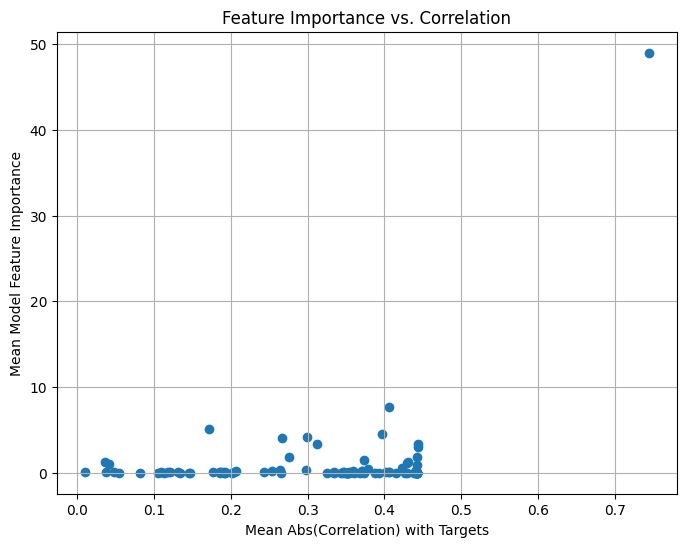

In [8]:
def _make_predictions_in_1_function(X_train, y_train, X_val, y_val, device):
    predictor = MultiOutputModelPredictor(device)

    print(f"======== Results =======")
    # rmse_linreg, _ = predictor.predict_linear_reg(X_train, y_train, X_val, y_val)
    # print(f"LinReg RMSE: {rmse_linreg:.3f}")

    # rmse_ridge, _ = predictor.predict_linear_reg_ridge(X_train, y_train, X_val, y_val)
    # print(f"Ridge RMSE: {rmse_ridge:.3f}")

    # rmse_lgb, _ = predictor.predict_lightgbm(X_train, y_train, X_val, y_val)
    # print(f"LGBM RMSE: {rmse_lgb:.3f}")

    rmse_cat, _, importances = predict_catboost(X_train, y_train, X_val, y_val)
    print(f"Catboost RMSE: {rmse_cat:.3f}")

    # rmse_rf, _  = predictor.predict_randomforest(X_train, y_train, X_val, y_val)
    # print(f"RF RMSE: {rmse_rf:.3f}")

    return importances#, y_val, y_scaler


from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, mean_squared_error
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))
rmse_scorer = make_scorer(rmse, greater_is_better=False)

def train_models_in_1_dataset(y_df_expanded, joined_log_spatial_df, main_folder, device):
    """Edited to do everything in 1 dataset"""
    marathon_run_col = "marathon_run"
    wafer_col        = "wafer"
    run_col          = "#run"

    # convert wafer col to str, maybe it helps
    # joined_log_spatial_df = joined_log_spatial_df.with_columns(pl.col(wafer_col).cast(str))
    # ================

    preprocessor = DataPreprocessor()

    X = joined_log_spatial_df.to_pandas().drop(columns=[wafer_col, marathon_run_col, run_col], errors='ignore')
    y = y_df_expanded.drop(marathon_run_col, wafer_col).to_pandas()

    X_train: pd.DataFrame
    y_train: np.ndarray
    X_val:   pd.DataFrame
    y_val:   np.ndarray
    X_train, y_train, X_val, y_val, y_scaler = preprocessor.scale_and_split_data(X, y)
    # X_train, y_train, X_val, y_val, wafer_x_scalers, wafer_y_scalers = preprocessor.scale_per_wafer_and_split_data(X, y, wafer_col="wafer", test_size=0.2)

    numeric_cols  = X_train.select_dtypes(include=[np.number]).columns
    zero_var_cols = X_train[numeric_cols].columns[X_train[numeric_cols].var() == 0].tolist()
    X_train_clean = X_train.drop(columns = zero_var_cols)
    X_val_clean   = X_val.drop(columns = zero_var_cols)

    # ============ bit about feature importance
    importances = _make_predictions_in_1_function(X_train_clean, y_train, X_val_clean, y_val, device)

    mean_importance        = importances.mean(axis=0)
    top_indices_sorted     = mean_importance.argsort()[::-1]
    feature_names          = X_train_clean.columns.to_list()
    features_by_importance = [feature_names[i] for i in top_indices_sorted]
    print(features_by_importance)
    N_top_features         = math.floor(0.30 * len(features_by_importance))
    columns_to_keep        = features_by_importance[:N_top_features]
    X_train_clean_light    = X_train_clean[columns_to_keep]
    X_val_clean_light      = X_val_clean[columns_to_keep]
    
    model  = RandomForestRegressor()
    scores = cross_val_score(model, X_train_clean_light, y_train, scoring=rmse_scorer, cv=5)
    print(f"CV RMSE mean: {-scores.mean():.3f}")
    importances = _make_predictions_in_1_function(X_train_clean_light, y_train, X_val_clean_light, y_val, device)
    # ============

    # =========
    correlations = pd.DataFrame({
        f"target_{i}": X_train_clean.corrwith(pd.Series(y_train[:, i], index=X_train_clean.index)).abs()
        for i in range(y_train.shape[1])})

    # Average correlations across all targets
    mean_correlations = correlations.mean(axis=1)

    # Model importances (make sure index aligns with X_train_clean.columns)
    importances_mean = pd.Series(mean_importance, index=X_train_clean.columns)

    # Plot correlation vs importance
    plt.figure(figsize=(8,6))
    plt.scatter(mean_correlations, importances_mean)
    plt.xlabel("Mean Abs(Correlation) with Targets")
    plt.ylabel("Mean Model Feature Importance")
    plt.title("Feature Importance vs. Correlation")
    plt.grid(True)
    plt.show()
    # ============

    return importances

importances = train_models_in_1_dataset(y_df_expanded, joined_log_spatial_df_no_str, main_folder, device)


In [81]:
joined_log_spatial_df_no_str.head()

wafer,#run,common signal_14_step4,common signal_39_step4,common signal_40_step4,common signal_41_step4,common signal_43_step4,common signal_44_step4,common signal_45_step4,common signal_48_step4,common signal_49_step4,common signal_50_step4,common signal_51_step4,common signal_52_step4,common signal_53_step4,common signal_54_step4,common signal_55_step4,common signal_57_step4,common signal_58_step4,common signal_59_step4,common signal_60_step4,common signal_61_step4,common signal_62_step4,common signal_63_step4,common signal_64_step4,common signal_65_step4,common signal_69_step4,common signal_70_step4,common signal_71_step4,common signal_73_step4,common signal_78_step4,common signal_80_step4,common signal_82_step4,common signal_83_step4,common signal_84_step4,common signal_85_step4,common signal_86_step4,…,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109
i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
2,1.0,0.0,0.0,0.0,0.0,2.111,14.51,0.0,63.1,4.6,0.4,64.5,0.4,-0.1,0.5,0.4,0.6,0.4,0.1,65.2,0.6,1.7,0.6,0.4,1.6,63.2,13.3,1.6,400.0,0.0,2000.1,0.94,2.5,0.3,133.6,134.7,…,140,140,140,140,140,140,140,140,140,140,140,140,140,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148
1,1.0,0.0,0.0,0.0,0.0,2.111,14.51,0.0,63.1,4.6,0.4,64.5,0.4,-0.1,0.5,0.4,0.6,0.4,0.1,65.2,0.6,1.7,0.6,0.4,1.6,63.2,13.3,1.6,400.0,0.0,2000.1,0.94,2.5,0.3,133.6,134.7,…,140,140,140,140,140,140,140,140,140,140,140,140,140,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148
3,1.0,0.0,0.0,0.0,0.0,2.111,14.51,0.0,63.1,4.6,0.4,64.5,0.4,-0.1,0.5,0.4,0.6,0.4,0.1,65.2,0.6,1.7,0.6,0.4,1.6,63.2,13.3,1.6,400.0,0.0,2000.1,0.94,2.5,0.3,133.6,134.7,…,140,140,140,140,140,140,140,140,140,140,140,140,140,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148
4,1.0,0.0,0.0,0.0,0.0,2.111,14.51,0.0,63.1,4.6,0.4,64.5,0.4,-0.1,0.5,0.4,0.6,0.4,0.1,65.2,0.6,1.7,0.6,0.4,1.6,63.2,13.3,1.6,400.0,0.0,2000.1,0.94,2.5,0.3,133.6,134.7,…,140,140,140,140,140,140,140,140,140,140,140,140,140,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148
2,1.0,0.0,1.0,1.0,1.0,1.797,13.01,0.0,36.0,0.6,0.0,64.5,0.4,-0.1,0.5,0.4,0.6,0.4,0.1,65.2,0.5,0.0,0.6,0.4,0.0,65.7,0.6,0.0,0.0,0.0,0.0,0.73,1.4,0.28,133.6,134.7,…,140,140,140,140,140,140,140,140,140,140,140,140,140,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148


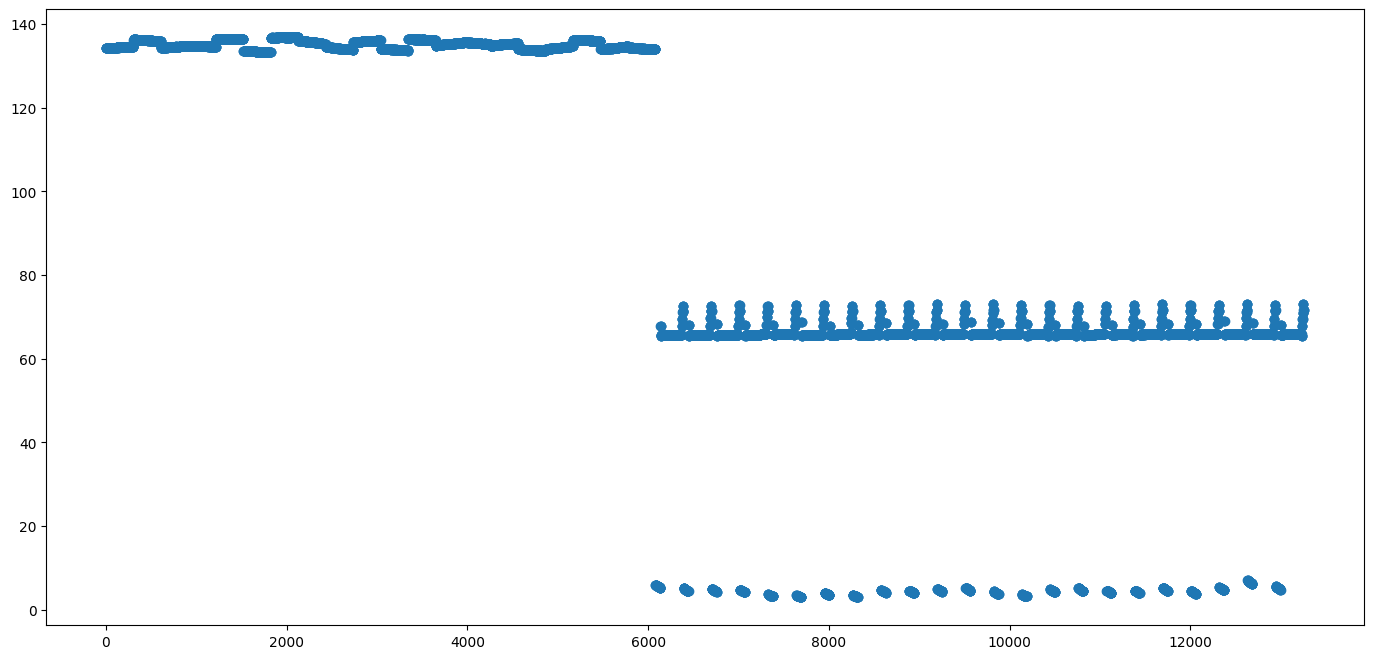

In [80]:
# ['rc3 signal_1_step4', 'common signal_88_step4', 'common signal_64_step4', 'common signal_92_step4', 'common signal_91_step4', 'common signal_90_step4', 'common signal_87_step4', 'common signal_52_step4', 'common signal_85_step4', 'common signal_86_step4', 'common signal_43_step4', 'common signal_61_step4', 'rc3 signal_0_step4', 'rc3 signal_3_step4', 'common signal_58_step4', 'rc3 signal_2_step4', 'common signal_89_step4', 'common signal_60_step4', 'common signal_70_step4', 'common signal_62_step4', 'common signal_54_step4', 'common signal_69_step4', 'common signal_44_step4', 'common signal_63_step4', 'rc4 signal_0_step4', 'common signal_83_step4', 'common signal_55_step4', 'rc1 signal_0_step4', 'common signal_57_step4', 'common signal_111_step4', 'common signal_48_step4', 'common signal_82_step4', 'rc1 signal_1_step4', 'common signal_80_step4', 'common signal_84_step4', 'common signal_65_step4', 'rc4 signal_2_step4', 'rc2 signal_5_step4', 'common signal_40_step4', 'rc2 signal_6_step4', 'common signal_157_step4', 'rc2 signal_2_step4', 'rc2 signal_1_step4', 'common signal_78_step4', 'rc1 signal_3_step4', 'rc1 signal_6_step4', 'rc1 signal_5_step4', 'rc4 signal_3_step4', 'common signal_39_step4', 'common signal_73_step4', 'rc4 signal_5_step4', 'rc1 signal_2_step4', 'rc2 signal_3_step4', 'rc4 signal_6_step4', 'common signal_71_step4', 'common signal_103_step4', 'common signal_122_step4', 'rc2 signal_0_step4', 'rc3 signal_6_step4', 'common signal_93_step4', 'common signal_94_step4', 'rc4 signal_1_step4', 'common signal_41_step4', 'common signal_121_step4', 'common signal_49_step4', 'common signal_123_step4', 'common signal_113_step4', 'common signal_50_step4', 'common signal_155_step4', 'common signal_104_step4', 'common signal_108_step4', 'common signal_51_step4', 'common signal_153_step4', 'common signal_98_step4', 'common signal_45_step4', 'common signal_95_step4', 'common signal_59_step4', 'common signal_74_step4', 'rc3 signal_5_step4', 'common signal_14_step4', 'common signal_97_step4', 'common signal_77_step4', 'common signal_118_step4', 'common signal_156_step4', 'common signal_96_step4', 'common signal_107_step4', 'common signal_99_step4', 'common signal_154_step4', 'common signal_115_step4', 'common signal_53_step4', 'common signal_120_step4', 'common signal_102_step4', 'common signal_110_step4', 'common signal_105_step4', 'common signal_46_step4', 'common signal_119_step4', '104', 'common signal_114_step4', 'common signal_112_step4', 'common signal_109_step4', 'common signal_100_step4', 'common signal_79_step4', 'common signal_36_step4']

plt.figure(figsize=(17, 8))
# y_values = joined_log_spatial_df_no_str['rc3 signal_1_step4']
y_values = joined_log_spatial_df_no_str['common signal_88_step4']
x_values = range(len(y_values))
plt.scatter(x_values, y_values)
plt.show()


In [83]:

# how to see importance of features:
# corr(feature, y)

# feature_importances_

# SHAP


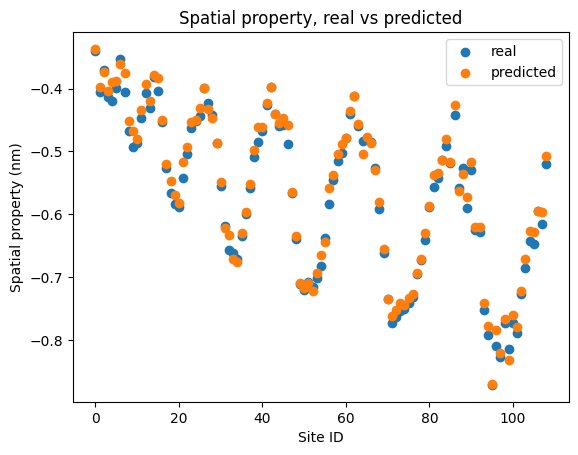

In [ ]:
which_row = 1

fig, ax = plt.subplots()
ax.scatter(range(len(y_val[0])), y_val[which_row], label='real')
ax.scatter(range(len(y_val[0])), y_pred_cat[which_row], label='predicted')
ax.set_xlabel("Site ID")
ax.set_ylabel("Spatial property (nm)")
ax.set_title("Spatial property, real vs predicted")
ax.legend()
plt.show()

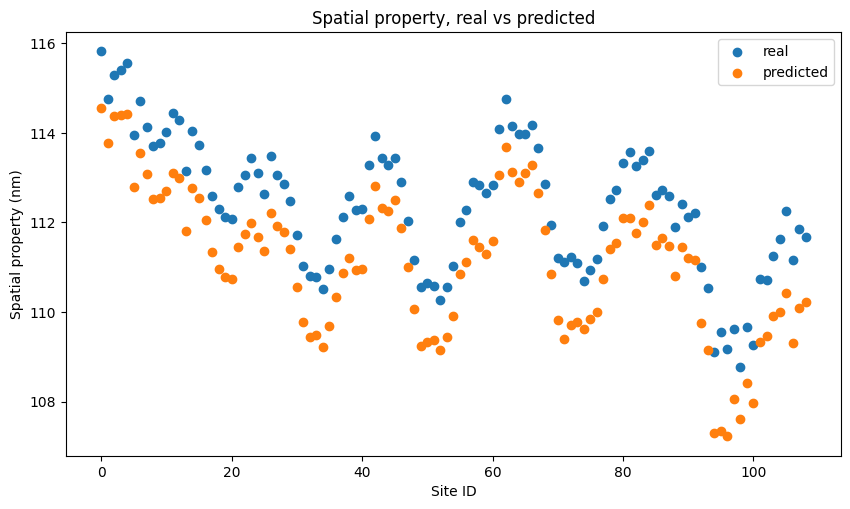

In [ ]:
which_row = 1
y_real_values = (y_df_expanded.row(which_row))[2:]

y_pred_cat_original_scale = y_scaler.inverse_transform(y_pred_cat)
y_val_original_scale = y_scaler.inverse_transform(y_val)
y_pred_values = y_val_original_scale[which_row]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.scatter(range(len(y_real_values)), y_real_values, label='real')
ax.scatter(range(len(y_pred_values)), y_pred_values, label='predicted')
ax.set_xlabel("Site ID")
ax.set_ylabel("Spatial property (nm)")
ax.set_title("Spatial property, real vs predicted")
ax.legend()
plt.show()


In [ ]:
# code just to break the run
beep_sound(4)

x-1

# col "common signal_49_step4" has big outliers

NameError: name 'x' is not defined

In [ ]:
"""Hyperparam search"""

predictor    = MultiOutputModelPredictor(device)
preprocessor = DataPreprocessor()

marathon_run_col = "marathon_run"
wafer_col        = "wafer"

y = y_df_expanded.drop(marathon_run_col).to_pandas()
X = joined_log_df_with_spatial_df.to_pandas().drop(columns=[wafer_col, marathon_run_col], errors='ignore')
X = preprocessor.drop_certain_cols_from_df(X, [marathon_run_col])

X_train: pd.DataFrame
y_train: np.ndarray
X_val:   pd.DataFrame
y_val:   np.ndarray
X_train, y_train, X_val, y_val, y_scaler = preprocessor.scale_and_split_data(X, y)

numeric_cols  = X_train.select_dtypes(include=[np.number]).columns
zero_var_cols = X_train[numeric_cols].columns[X_train[numeric_cols].var() == 0].tolist()
X_train = X_train.drop(columns=zero_var_cols)
X_val   = X_val.drop(columns=zero_var_cols)

# best_model = predictor.tune_catboost_hyperparams(X_train, y_train)
best_model = predictor.tune_lightgbm_hyperparams(X_train, y_train)


Combo 1/4: est=50, lr=0.15, depth=6, lambda=3, leaves=64, bag_frac=1.0


KeyboardInterrupt: 

In [ ]:
for i in range(5):
    beep_sound()

# 0.4 --> 0.1023
# 0.5 --> 0.0978

# Combo 1/8: est=50, lr=0.46, depth=8, lambda=3, leaves=64, bag_frac=1.0
# Avg RMSE: 0.0833

# Combo 5/12: est=50, lr=0.4, depth=6, lambda=3, leaves=64, bag_frac=1.0
# Avg RMSE: 0.0822


In [ ]:
def join_features_targets(big_log_df, target_df):
    # target columns except marathon_run
    target_cols = [str(i) for i in range(1, 110)]
    
    # merge on marathon_run
    full_df = big_log_df.merge(target_df, on='marathon_run', how='left')
    
    # features: drop target columns + marathon_run if not needed as feature
    X = full_df.drop(columns=target_cols + ['marathon_run'])
    
    # targets
    y = full_df[target_cols]
    
    return X, y


def train_one_model_for_all_wafers(y_df_dict, radius_wide_dict, big_log_df, marathon_run_col, target_cols, device):
    predictor    = MultiOutputModelPredictor(device)
    preprocessor = DataPreprocessor()
    wafer_col    = "wafer"

    # Combine all y dfs into one with wafer column
    y_dfs = []
    for k, df in y_df_dict.items():
        y_dfs.append(df.with_columns(pl.lit(k+1).alias(wafer_col)))
    combined_y_df = pl.concat(y_dfs, how="vertical")

    # Combine all radius dfs into one with wafer column
    radius_dfs = []
    for k, df in radius_wide_dict.items():
        radius_dfs.append(df.with_columns(pl.lit(k+1).alias(wafer_col)))
    combined_radius_df = pl.concat(radius_dfs, how="vertical")

    # Flatten last rows of big_log_df by marathon_run
    processed_log_df = asm._flatten_last_n_rows(big_log_df, marathon_run_col, num_of_last_rows=1)

    # Join features with radius info on marathon_run and wafer
    features_df = processed_log_df.join(
        combined_radius_df,
        on  = [marathon_run_col, wafer_col],
        how = "left")

    # Join features with targets on marathon_run and wafer
    full_df = features_df.join(
        combined_y_df,
        on  = [marathon_run_col, wafer_col],
        how = "inner")

    # Prepare X and y
    y = full_df.select(target_cols).to_pandas()
    X = full_df.drop(target_cols + [marathon_run_col, wafer_col]).to_pandas()

    X = preprocessor.drop_certain_cols_from_df(X, [marathon_run_col])

    # Scale and split
    X_train, y_train, X_val, y_val, y_scaler = preprocessor.scale_and_split_data(X, y)
    X_train = X_train.fillna(0)
    X_val   = X_val.fillna(0)

    # Drop zero variance cols
    zero_var_cols = X_train.columns[X_train.var() == 0].tolist()
    X_train = X_train.drop(columns=zero_var_cols)
    X_val   = X_val.drop(columns=zero_var_cols)

    # Train all models and print results
    rmse_linreg, _ = predictor.predict_linear_reg(X_train, y_train, X_val, y_val)
    rmse_ridge, _  = predictor.predict_linear_reg_ridge(X_train, y_train, X_val, y_val)
    rmse_lgb, _    = predictor.predict_lightgbm(X_train, y_train, X_val, y_val)
    # rmse_cat, _ = predictor.predict_catboost(X_train, y_train, X_val, y_val)
    rmse_rf, _     = predictor.predict_randomforest(X_train, y_train, X_val, y_val)

    print(f"LinReg RMSE: {rmse_linreg:.3f}")
    print(f"Ridge RMSE: {rmse_ridge:.3f}")
    print(f"LGBM RMSE: {rmse_lgb:.3f}")
    # print(f"Catboost RMSE: {rmse_cat:.3f}")
    print(f"RF RMSE: {rmse_rf:.3f}")

    return {"linreg_rmse": rmse_linreg,
            "ridge_rmse":  rmse_ridge,
            "lgbm_rmse":   rmse_lgb,
            # "catboost_rmse": rmse_cat,
            "rf_rmse":     rmse_rf,}

target_cols = [str(i) for i in range(1, 110)]  # '1' to '109'

results = train_one_model_for_all_wafers(
    y_df_dict        = y_df_dict,
    radius_wide_dict = radius_wide_dict,
    big_log_df       = big_log_df,
    marathon_run_col = "marathon_run",
    target_cols      = target_cols,
    device           = device)

print(results)

# combined_log_df["wafer"]
# print(y_df_dict[0].columns)


X_train max: 23.703703703703702
X_val max: 16.14814814814815
LinReg RMSE: 0.005
Ridge RMSE: 0.003
LGBM RMSE: 0.006
RF RMSE: 0.004
{'linreg_rmse': 0.005200040814903912, 'ridge_rmse': 0.0033444143613188125, 'lgbm_rmse': 0.006161686739610378, 'rf_rmse': 0.004331386017582799}


In [ ]:

# df = pl.read_csv(f'../ASM_data/2. marathon0/logs/Step1.csv', null_values=["", "NA", "null"], ignore_errors=True, separator=",")
pdf         = pd.read_csv(f'../ASM_data/2. marathon0/logs/Step4.csv', decimal='.')
pdf_numeric = pdf.select_dtypes(include='number') # removes strings
df          = pl.from_pandas(pdf_numeric)

df.head()

#Run,Common signal_0,Common signal_1,Common signal_2,Common signal_3,Common signal_4,Common signal_5,Common signal_6,Common signal_7,Common signal_8,Common signal_9,Common signal_10,Common signal_11,Common signal_12,Common signal_13,Common signal_14,Common signal_15,Common signal_16,Common signal_17,Common signal_18,Common signal_19,Common signal_20,Common signal_21,Common signal_22,Common signal_23,Common signal_24,Common signal_25,Common signal_26,Common signal_27,Common signal_28,Common signal_29,Common signal_30,Common signal_31,Common signal_32,Common signal_33,Common signal_34,Common signal_35,…,Common signal_81,Common signal_82,Common signal_83,Common signal_84,Common signal_85,Common signal_86,Common signal_87,Common signal_88,Common signal_89,Common signal_90,Common signal_91,Common signal_92,Common signal_93,Common signal_94,Common signal_95,Common signal_96,Common signal_97,Common signal_98,Common signal_99,Common signal_100,Common signal_101,RC1 signal_0,RC1 signal_1,RC1 signal_2,RC1 signal_3,RC2 signal_0,RC2 signal_1,RC2 signal_2,RC2 signal_3,RC3 signal_0,RC3 signal_1,RC3 signal_2,RC3 signal_3,RC4 signal_3,RC4 signal_0,RC4 signal_1,RC4 signal_2
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,1,1,1,…,0,0.94,2.5,0.3,133.6,134.7,134.3,134.2,37.6,39.8,14.2,82.4,1,1,1,1,1,1,1,1,1,347.0,199.9,32.7,34.1,341.9,200.1,31.5,29.3,342.0,200.0,28.1,32.4,25.6,342.0,200.0,29.1
1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,1,1,1,…,0,0.95,2.5,0.34,133.6,134.7,134.3,134.2,37.6,39.8,14.2,82.4,1,1,1,1,1,1,1,1,1,347.0,199.9,32.7,34.1,341.9,200.1,31.5,29.3,342.0,200.0,28.1,32.4,25.6,342.0,200.0,29.1
1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,1,1,1,…,0,1.13,2.3,0.38,133.6,134.7,134.3,134.2,37.6,39.9,14.1,82.4,1,1,1,1,1,1,1,1,1,346.9,199.9,33.0,33.8,341.9,200.1,31.0,29.2,342.0,200.0,28.7,32.2,25.2,342.0,200.0,28.7
1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,1,1,1,…,0,1.08,2.3,0.4,133.6,134.7,134.3,134.2,37.6,39.9,14.1,82.4,1,1,1,1,1,1,1,1,1,346.9,199.9,33.0,33.8,341.9,200.1,31.0,29.2,342.0,200.0,28.7,32.2,25.2,342.0,200.0,28.7
1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,1,1,1,…,0,1.03,2.5,0.42,133.7,134.7,134.3,134.2,37.5,40.0,14.0,82.4,1,1,1,1,1,1,1,1,1,346.9,199.9,33.0,33.4,341.9,200.1,30.8,28.4,342.0,200.1,29.2,31.6,24.6,342.0,200.0,28.3


3217
[0.         0.         0.         ... 0.00195312 0.00195312 0.00195312]


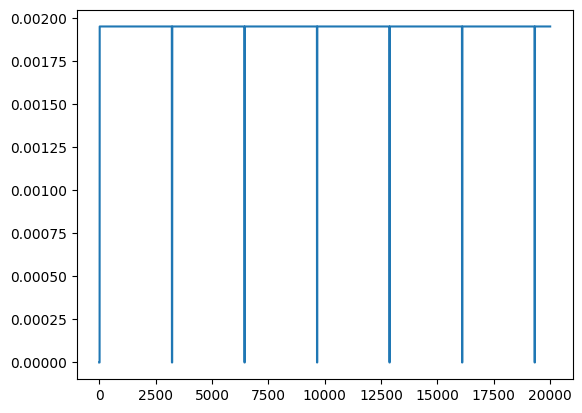

In [ ]:
# plot_all_columns_in_df(pdf[pdf.columns[:10]])

df2 = remove_constant_valued_cols(df)
df_scaled = StandardScaler().fit_transform(df2)

num_rows_subsample = 500_000
if df_scaled.shape[0] > num_rows_subsample:
    idx = np.random.choice(df_scaled.shape[0], num_rows_subsample, replace=False)
    df_scaled_sample = df_scaled[idx]
else:
    df_scaled_sample = df_scaled

df_scaled = pl.DataFrame(df_scaled)  # Only do this if df_scaled is a NumPy array
# plot_all_columns_in_df(df_scaled.select(df_scaled.columns[:20]))
# plot_all_columns_in_df(df2.select(df2.columns[:20]))


# # plt.plot(df2[df2.columns[3]].to_numpy()[:200_000])
# y1 = df2[df2.columns[3]].to_numpy()[:5_0000]
# x1 = np.arange(len(y1))
# plt.scatter(x1, y1)#, s=1)  # s=1 for smaller points


def find_square_periodicity_of_feature(signal):
    """Requires a square function"""
    durations   = np.diff(np.where(np.diff(signal) != 0)[0])
    periods     = durations[::2] + durations[1::2]  # Sum long+short phases
    estimated_p = int(np.round(np.median(periods)))
    return estimated_p

def sin_encode(signal, periodicity):
    sin_encoded = np.sin(2 * np.pi * signal/periodicity)
    return sin_encoded

signal = df2[:, 3].to_numpy()
periodicity = find_square_periodicity_of_feature(signal)
sin_encoded = sin_encode(signal, periodicity)
print(periodicity)
print(sin_encoded)

plt.plot(sin_encoded[:20_000])

# p = 1
# sin_encoded = np.sin(2* np.pi* x/p)

# data_dimensionality = estimate_dataset_dimensionality(df_scaled_sample, 150)
# print(f"Recommended latent layer size: {data_dimensionality:.1f}")

# beep_sound(3, 0)

In [ ]:
import umap
reducer   = umap.UMAP()
embedding = reducer.fit_transform(df_scaled)
embedding.shape



KeyboardInterrupt: 

In [ ]:

main_folder   = "../ASM_data"
dict_of_spatial_files = {'file1': {'path': f"{main_folder}/2. marathon0/Wafer performance/Spatial property after step 4.csv", 'marathon': 0},
                       'file2': {'path': f"{main_folder}/3. marathon1/Wafer performance/Spatial property.csv", 'marathon': 1}}

dict_of_log_files = {'file1': {'path': f"{main_folder}/2. marathon0/logs/Step1.csv", 'step': 1, 'marathon': 0},
                     'file2': {'path': f"{main_folder}/2. marathon0/logs/Step2.csv", 'step': 2, 'marathon': 0},
                     'file3': {'path': f"{main_folder}/2. marathon0/logs/Step3.csv", 'step': 3, 'marathon': 0},
                     'file4': {'path': f"{main_folder}/2. marathon0/logs/Step4.csv", 'step': 4, 'marathon': 0},
                     'file5': {'path': f"{main_folder}/3. marathon1/logs/Step1.csv", 'step': 1, 'marathon': 1},
                     'file6': {'path': f"{main_folder}/3. marathon1/logs/Step2.csv", 'step': 2, 'marathon': 1},
                     'file7': {'path': f"{main_folder}/3. marathon1/logs/Step3.csv", 'step': 3, 'marathon': 1},
                     'file8': {'path': f"{main_folder}/3. marathon1/logs/Step4.csv", 'step': 4, 'marathon': 1},}

# def train_models(y_df_dict, radius_wide_dict, main_folder, num_wafers, device):
#     predictor    = MultiOutputModelPredictor(device)
#     preprocessor = DataPreprocessor()

#     marathon_run_col = "marathon_run"
#     wafer_col        = "wafer"

#     total_rmse_lgb, total_rmse_cat, total_rmse_rf, total_rmse_linreg, total_rmse_ridge = 0, 0, 0, 0, 0
#     for wafer_idx in range(num_wafers):
#         wafer_log_df             = pl.read_parquet(f"{main_folder}/{parquet_folder_name}/{wafer_col}_{wafer_idx+1}_log.parquet")
#         # processed_wafer_log_df   = _compute_log_df_grouped_stats(wafer_log_df, 'marathon_run')
#         processed_wafer_log_df   = asm._flatten_last_n_rows(wafer_log_df, marathon_run_col)
#         break
#     return processed_wafer_log_df

master_spatial_df, spatial_df_dict, y_df_dict, radius_wide_dict = asm.load_spatial_csv_and_create_targets(dict_of_spatial_files, main_folder, save=False)
unique_marathon_runs_list = list(master_spatial_df["marathon_run"].unique())
master_log_df = asm.load_process_and_combine_log_csv_files(dict_of_log_files, log_processor, unique_marathon_runs_list, step_col_name, main_folder, save=False)
master_log_df = remove_constant_valued_cols(master_log_df)
# asm.split_log_df_by_wafer_and_save_to_parquet(master_log_df, NUM_WAFERS, main_folder, log_processor, overwrite = False)
# processed_wafer_log_df = train_models(y_df_dict, radius_wide_dict, main_folder, NUM_WAFERS, device)



In [ ]:
df1 = pd.read_csv(f"{main_folder}/2. marathon0/logs/Step4.csv")
df2 = pd.read_csv(f"{main_folder}/3. marathon1/logs/Step4.csv")

print(df1.shape)
print(df2.shape)


(728932, 120)
(756555, 197)


In [ ]:
def read_csv_and_lowercase_cols_names(file_path: str) -> pl.DataFrame:
    """Read CSV into Polars DataFrame and title-case column names after stripping spaces"""
    df = pl.read_csv(file_path, ignore_errors=True)
    df = df.rename({c: c.strip().title() for c in df.columns})
    return df

count_missing_values_in_df(dict_of_log_files[1])


In [ ]:
y_pred_cat.shape
y_pred_unscaled = y_scaler.inverse_transform(y_pred_cat)

type(y_pred_cat)

NameError: name 'y_pred_cat' is not defined

In [ ]:
y_pred_unscaled = y_scaler.inverse_transform(y_pred_cat)

plt.scatter(range(len(y_full_pd.iloc[1].values)), y_full_pd.iloc[1].values,
            label="True", facecolors='none', edgecolors='blue', s=8)
plt.scatter(range(len(y_pred_unscaled[1])), y_pred_unscaled[1],
            label="Predicted", facecolors='none', edgecolors='orange', s=8)
# plt.plot(y_full_pd.iloc[1].values, label="True")
# plt.plot(y_pred_unscaled[1], label="Predicted")
plt.legend()
plt.title("y_predicted vs y_actual")
plt.xlabel("Site ID (coordinate)")
plt.ylabel("Spatial property")
plt.show()


In [ ]:
# hyperparam search

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'estimator__num_leaves': [20, 31, 40, 50],
    'estimator__max_depth': [-1, 5, 10, 20],
    'estimator__min_data_in_leaf': [10, 20, 30],
    'estimator__learning_rate': [0.01, 0.05, 0.1],
    'estimator__n_estimators': [100, 500, 1000]}

# model = MultiOutputRegressor(xgb.XGBRegressor(objective='reg:squarederror', verbosity=0))
model = MultiOutputRegressor(LGBMRegressor(objective='regression', verbosity=-1))

search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV RMSE:", (-search.best_score_)**0.5)



##### Spatial data (M)

In [ ]:
def plot_wafer_property(df, property_col, title):
    plt.figure(figsize=(9, 5))
    for rc_value, group in df.group_by("RC"):
        x = group["#Run"].to_list()
        y = group[property_col].to_list()
        plt.scatter(x, y, label=f'RC {rc_value}', s=20)
    plt.xlabel("#Run")
    plt.ylabel(property_col)
    plt.title(title)
    plt.legend()
    plt.show()

plot_wafer_property(wafer_df, "Wafer property summary 1", "Wafer Property 1")
plot_wafer_property(wafer_df, "Wafer property summary 2", "Wafer Property 2")


##### Import timeseries data (S)

In [ ]:
"""Load data and make parquet files out of it"""

should_we_save_parquet_files = False

def _save_df_as_parquet_file(df: pl.dataframe, saving_location: str):
    df.write_parquet(saving_location)

def remove_unchanging_cols_from_df_and_save(df: pl.dataframe, col_name: str, should_we_save_parquet_files: bool) -> None:
    for run_id in df[col_name].unique().to_list():
        df_per_run    = df.filter(pl.col(col_name) == run_id)
        constant_cols = [col for col in df_per_run.columns
                     if df_per_run[col].dtype in [pl.Int64, pl.Float64] and
                        #  df_per_run.select(pl.col(col).filter(pl.col(col) != 0)).height == 0]
                         df_per_run.select(pl.col(col).n_unique()).item() == 1]
        df_per_run_filtered = df_per_run.drop(constant_cols)
        saving_location = f"{parquet_subfolder}/run_{run_id}.parquet"
        if should_we_save_parquet_files:
            _save_df_as_parquet_file(df_per_run_filtered, saving_location)

remove_unchanging_cols_from_df_and_save(log_df, "#Run", should_we_save_parquet_files)

# =============
# before making funcrtion:

# if should_we_save_parquet_files:
#     for run_id in log_df["#Run"].unique().to_list():
#         df_per_run = log_df.filter(pl.col("#Run") == run_id)
#         zero_cols  = [col for col in df_per_run.columns
#                      if df_per_run[col].dtype in [pl.Int64, pl.Float64] and
#                         #  df_per_run.select(pl.col(col).filter(pl.col(col) != 0)).height == 0]
#                          df_per_run.select(pl.col(col).n_unique()).item() == 1]
#         df_per_run_filtered = df_per_run.drop(zero_cols)
#         df_per_run_filtered.write_parquet(f"{parquet_subfolder}/run_{run_id}.parquet")


##### Timeseries data (S)

In [ ]:
run_number   = 15
parquet_file = f"./ASM_data/3. marathon1/Logs/split_by_run/run_{run_number}.parquet"
df           = pl.read_parquet(parquet_file)
df_pd        = df.to_pandas()
df_numeric   = df.select(pl.col(pl.NUMERIC_DTYPES))
X_np         = df_numeric.to_numpy()
X_scaled     = StandardScaler().fit_transform(X_np)

num_cols_to_plot = len(df_pd.columns)
num_rows         = math.ceil(math.sqrt(num_cols_to_plot))
num_cols_grid    = math.ceil(num_cols_to_plot / num_rows)

axes = df_pd.plot(subplots=True, figsize=(14, 12), layout=(num_rows, num_cols_grid), sharex=True, legend=False)

if isinstance(axes, np.ndarray):
    axes_flat = axes.flatten()
else:
    axes_flat = [axes]

column_names = df_pd.columns.tolist()

for i, ax in enumerate(axes_flat):
    if i < num_cols_to_plot: # Only set title for actual plots
        ax.set_title(column_names[i], fontsize='xx-small')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])

for i in range(num_cols_to_plot, len(axes_flat)):
    axes_flat[i].set_visible(False)

plt.tight_layout()
plt.suptitle(f'Run #{run_number} {log_file}', fontsize='large', y=1.02) # Adjust y to prevent overlap
plt.show()